# Cycle Data Analysis

* Analysis by: Theodore Chidi-Maha
* Last Updated: Jun 4, 2026

## imports

In [31]:
import numpy as np
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt

## converting csv's

In [2]:
tripdata_path = '*.csv'
all_files = glob.glob(tripdata_path)

In [3]:
# articles = []

# for fname in files_complex+files_simple:
#   with open(fname) as f:
#     if fname.endswith('.en.0.txt'):
#       articles.append([f.read().strip(), 'complex', fname.split('/')[-1]])
#     else:
#       articles.append([f.read().strip(), 'simple', fname.split('/')[-1]])

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True, axis=0, join='outer')

In [4]:
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E555D9F8E9C2F56B,electric_bike,2025-11-04 00:09:07.792,2025-11-04 00:15:04.661,NaN,NaN,NaN,NaN,41.940000,-87.670000,41.940000,-87.670000,casual
1,EAEBE70DBF015886,electric_bike,2025-11-04 14:32:09.067,2025-11-04 14:36:43.998,NaN,NaN,NaN,NaN,41.900000,-87.640000,41.910000,-87.640000,casual
2,A42F8404F804E56E,electric_bike,2025-11-04 12:20:48.215,2025-11-04 12:21:01.630,NaN,NaN,NaN,NaN,41.890000,-87.630000,41.890000,-87.630000,casual
3,E49D01E38A1E074E,electric_bike,2025-11-04 12:17:16.548,2025-11-04 12:17:51.527,NaN,NaN,NaN,NaN,41.890000,-87.630000,41.890000,-87.630000,casual
4,9308F609195D2414,electric_bike,2025-11-04 08:16:27.979,2025-11-04 08:21:02.780,NaN,NaN,NaN,NaN,41.890000,-87.640000,41.880000,-87.640000,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697450,3EBF5095F5EDD850,electric_bike,2026-04-30 17:28:33.339,2026-04-30 17:33:55.678,Broadway & Ridge Ave,CHI00337,Winchester (Ravenswood) Ave & Balmoral Ave,CHI00630,41.984045,-87.660274,41.979762,-87.677530,member
5697451,9E8DA9D139892463,classic_bike,2026-04-29 18:54:07.910,2026-04-29 19:01:38.331,Broadway & Ridge Ave,CHI00337,Winchester (Ravenswood) Ave & Balmoral Ave,CHI00630,41.984045,-87.660274,41.979762,-87.677530,member
5697452,37C480C304D1D8C1,electric_bike,2026-04-09 15:49:52.265,2026-04-09 16:19:23.924,Wells St & Hubbard St,CHI00332,Francisco Ave & Foster Ave,CHI00638,41.889906,-87.634266,41.975633,-87.701419,member
5697453,27B1BFA25C7449F4,electric_bike,2026-04-21 15:37:19.424,2026-04-21 15:42:02.893,Wells St & Hubbard St,CHI00332,Wells St & Madison St,CHI02102,41.889906,-87.634266,41.881990,-87.634180,casual


### Deliverables – citing source
* Lyft Bikes and Scooters, LLC. (n.d.). 
* Data license agreement. Divvy Bikes. 
* Retrieved May 19, 2026, from https://divvy-tripdata.s3.amazonaws.com/index.html

## Cleaning/Preparing data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5697455 entries, 0 to 5697454
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 565.1+ MB


* converted started_at and ended_at to datetime

In [6]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [7]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5697455 entries, 0 to 5697454
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             5697455 non-null  object        
 1   rideable_type       5697455 non-null  object        
 2   started_at          5697455 non-null  datetime64[ns]
 3   ended_at            5697455 non-null  datetime64[ns]
 4   start_station_name  4481710 non-null  object        
 5   start_station_id    4481710 non-null  object        
 6   end_station_name    4417592 non-null  object        
 7   end_station_id      4417592 non-null  object        
 8   start_lat           5697455 non-null  float64       
 9   start_lng           5697455 non-null  float64       
 10  end_lat             5691598 non-null  float64       
 11  end_lng             5691598 non-null  float64       
 12  member_casual       5697455 non-null  object        
dtypes: datetime6

* remove rows that contain missing values

In [8]:
df.dropna(axis=0, inplace=True)

In [9]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 3782802 entries, 193 to 5697454
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             3782802 non-null  object        
 1   rideable_type       3782802 non-null  object        
 2   started_at          3782802 non-null  datetime64[ns]
 3   ended_at            3782802 non-null  datetime64[ns]
 4   start_station_name  3782802 non-null  object        
 5   start_station_id    3782802 non-null  object        
 6   end_station_name    3782802 non-null  object        
 7   end_station_id      3782802 non-null  object        
 8   start_lat           3782802 non-null  float64       
 9   start_lng           3782802 non-null  float64       
 10  end_lat             3782802 non-null  float64       
 11  end_lng             3782802 non-null  float64       
 12  member_casual       3782802 non-null  object        
dtypes: datetime64[n

* sort the dataframe by started_at in descending order

In [10]:
df.sort_values(by='started_at', axis=0, inplace=True)
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
5202966,DF25880DBE661F8D,classic_bike,2025-04-30 11:12:06.627,2025-05-01 00:34:11.236,Wilton Ave & Diversey Pkwy,TA1306000014,Sheffield Ave & Fullerton Ave,TA1306000016,41.932418,-87.652705,41.925616,-87.653657,casual
4990377,FAF5B0191BD819D9,classic_bike,2025-04-30 14:28:04.654,2025-05-01 09:06:43.007,Daley Center Plaza,TA1306000010,Streeter Dr & Grand Ave,13022,41.884241,-87.629634,41.892278,-87.612043,casual
4990378,D78D75D514058CA4,classic_bike,2025-04-30 14:28:32.047,2025-05-01 08:29:27.114,Daley Center Plaza,TA1306000010,Streeter Dr & Grand Ave,13022,41.884241,-87.629634,41.892278,-87.612043,casual
5221296,0787669DB22594C2,classic_bike,2025-04-30 14:28:35.860,2025-05-01 06:49:45.241,Daley Center Plaza,TA1306000010,Dusable Harbor,KA1503000064,41.884241,-87.629634,41.886976,-87.612813,casual
4831859,C1775B4534BAC573,classic_bike,2025-04-30 18:37:20.489,2025-05-01 14:06:43.076,Fairbanks St & Superior St,18003,Vincennes Ave & 79th St,24352,41.895748,-87.620104,41.750600,-87.634090,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5400632,4EBCC6DF233878B6,classic_bike,2026-04-30 23:57:58.221,2026-05-01 00:02:42.981,Green St & Randolph St,CHI01988,Clinton St & Madison St,CHI00233,41.883602,-87.648627,41.881660,-87.641150,member
5353515,41E2750A57535CF7,electric_bike,2026-04-30 23:58:04.347,2026-05-01 00:12:39.854,Albany Ave & Montrose Ave,CHI01768,Clarendon Ave & Junior Ter,CHI00395,41.961041,-87.705866,41.961004,-87.649603,casual
5302996,E923A7ACDD4A9293,classic_bike,2026-04-30 23:58:06.960,2026-05-01 00:00:34.820,Clinton St & Lake St,CHI01746,Wacker Dr & Washington St,CHI01787,41.885637,-87.641823,41.883143,-87.637242,casual
5400634,EAB7C279D822C763,classic_bike,2026-04-30 23:58:36.620,2026-05-01 00:02:45.401,Green St & Randolph St,CHI01988,Clinton St & Madison St,CHI00233,41.883602,-87.648627,41.881660,-87.641150,member


* one-hot encode the member_casual categorical data

In [11]:
df['member_casual'].value_counts()

member_casual
member    2440858
casual    1341944
Name: count, dtype: int64

In [12]:
def member_type(x):
    if x == "member":
        return 1
    return 0

In [13]:
df['member_type'] = df['member_casual'].apply(member_type)

In [14]:
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,member_type
5202966,DF25880DBE661F8D,classic_bike,2025-04-30 11:12:06.627,2025-05-01 00:34:11.236,Wilton Ave & Diversey Pkwy,TA1306000014,Sheffield Ave & Fullerton Ave,TA1306000016,41.932418,-87.652705,41.925616,-87.653657,casual,0
4990377,FAF5B0191BD819D9,classic_bike,2025-04-30 14:28:04.654,2025-05-01 09:06:43.007,Daley Center Plaza,TA1306000010,Streeter Dr & Grand Ave,13022,41.884241,-87.629634,41.892278,-87.612043,casual,0
4990378,D78D75D514058CA4,classic_bike,2025-04-30 14:28:32.047,2025-05-01 08:29:27.114,Daley Center Plaza,TA1306000010,Streeter Dr & Grand Ave,13022,41.884241,-87.629634,41.892278,-87.612043,casual,0
5221296,0787669DB22594C2,classic_bike,2025-04-30 14:28:35.860,2025-05-01 06:49:45.241,Daley Center Plaza,TA1306000010,Dusable Harbor,KA1503000064,41.884241,-87.629634,41.886976,-87.612813,casual,0
4831859,C1775B4534BAC573,classic_bike,2025-04-30 18:37:20.489,2025-05-01 14:06:43.076,Fairbanks St & Superior St,18003,Vincennes Ave & 79th St,24352,41.895748,-87.620104,41.750600,-87.634090,casual,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5400632,4EBCC6DF233878B6,classic_bike,2026-04-30 23:57:58.221,2026-05-01 00:02:42.981,Green St & Randolph St,CHI01988,Clinton St & Madison St,CHI00233,41.883602,-87.648627,41.881660,-87.641150,member,1
5353515,41E2750A57535CF7,electric_bike,2026-04-30 23:58:04.347,2026-05-01 00:12:39.854,Albany Ave & Montrose Ave,CHI01768,Clarendon Ave & Junior Ter,CHI00395,41.961041,-87.705866,41.961004,-87.649603,casual,0
5302996,E923A7ACDD4A9293,classic_bike,2026-04-30 23:58:06.960,2026-05-01 00:00:34.820,Clinton St & Lake St,CHI01746,Wacker Dr & Washington St,CHI01787,41.885637,-87.641823,41.883143,-87.637242,casual,0
5400634,EAB7C279D822C763,classic_bike,2026-04-30 23:58:36.620,2026-05-01 00:02:45.401,Green St & Randolph St,CHI01988,Clinton St & Madison St,CHI00233,41.883602,-87.648627,41.881660,-87.641150,member,1


* calculate trip length in hours and seconds

In [15]:
df['Trip_length [secs]'] = (df['ended_at'] - df['started_at']).dt.total_seconds()

* dropped coordinates of start/end locations from table, was unnecessary for analysis

In [16]:
df.drop(columns=['start_lat','start_lng','end_lat','end_lng'], inplace=True)

In [17]:
df['date'] = df['started_at'].dt.date
df['month'] = df['started_at'].dt.month
df['day'] = df['started_at'].dt.day
df['year'] = df['started_at'].dt.year
df['day_of_week'] = df['started_at'].dt.day_name()


* removed bad trips with negative trip lengths

In [19]:
df = df.loc[~(df['Trip_length [secs]'] <0)]

* converted ids and names from object to string

In [ ]:
df['ride_id'] = df['ride_id'].astype('string')
df['rideable_type'] = df['rideable_type'].astype('string')
df['start_station_name'] = df['start_station_name'].astype('string')
df['start_station_id'] = df['start_station_id'].astype('string')
df['end_station_name'] = df['end_station_name'].astype('string')
df['end_station_id'] = df['end_station_id'].astype('string')
df['member_casual'] = df['member_casual'].astype('string')
df['day_of_week'] = df['day_of_week'].astype('string')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3782783 entries, 5202966 to 5515107
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             string        
 1   rideable_type       string        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  string        
 5   start_station_id    string        
 6   end_station_name    string        
 7   end_station_id      string        
 8   member_casual       string        
 9   member_type         int64         
 10  Trip_length [secs]  float64       
 11  date                object        
 12  month               int32         
 13  day                 int32         
 14  year                int32         
 15  day_of_week         string        
dtypes: datetime64[ns](2), float64(1), int32(3), int64(1), object(1), string(8)
memory usage: 447.3+ MB


## Data Aggregation/Analysis

In [22]:
# Descriptive analysis on ride_length (all figures in seconds)
print("\nDescriptive statistics for ride_length:\n", df['Trip_length [secs]'].describe())


Descriptive statistics for ride_length:
 count    3.782783e+06
mean     9.537680e+02
std      2.076700e+03
min      7.400000e-02
25%      3.426660e+02
50%      5.908140e+02
75%      1.049371e+03
max      8.997826e+04
Name: Trip_length [secs], dtype: float64


In [23]:
# Compare members and casual users
print("\nRide length statistics grouped by member_casual:\n",
df.groupby('member_casual')['Trip_length [secs]'].agg(['mean', 'median', 'max', 'min']))


Ride length statistics grouped by member_casual:
                       mean    median        max    min
member_casual                                         
casual         1328.273709  761.6740  89978.262  0.132
member          747.870926  522.7415  89906.901  0.074


In [ ]:
# Order the days of the week for correct sorting for analysis
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

In [78]:
# See the average ride time by each day for members vs casual users
print("\nAverage ride length by member type and day of the week:\n",
df.groupby(['member_casual', 'day_of_week'], observed=True)['Trip_length [secs]'].mean())


Average ride length by member type and day of the week:
 member_casual  day_of_week
casual         Sunday         1532.816545
               Monday         1312.967474
               Tuesday        1162.577950
               Wednesday      1095.511062
               Thursday       1172.843991
               Friday         1302.925094
               Saturday       1499.613863
member         Sunday          828.988681
               Monday          725.819682
               Tuesday         722.667579
               Wednesday       714.984846
               Thursday        720.005805
               Friday          744.050487
               Saturday        825.448256
Name: Trip_length [secs], dtype: float64


In [81]:
print("\nMost frequented start stations by member type and day of the week:\n")
df.groupby(['member_casual', 'day_of_week'], observed=True)['start_station_name'].agg(lambda x: x.mode()[0]).reset_index()


Most frequented start stations by member type and day of the week:



,member_casual,day_of_week,start_station_name
0,casual,Sunday,Navy Pier
1,casual,Monday,Navy Pier
2,casual,Tuesday,Navy Pier
3,casual,Wednesday,DuSable Lake Shore Dr & Monroe St
4,casual,Thursday,DuSable Lake Shore Dr & Monroe St
5,casual,Friday,Navy Pier
6,casual,Saturday,Navy Pier
7,member,Sunday,DuSable Lake Shore Dr & North Blvd
8,member,Monday,Clinton St & Washington Blvd
9,member,Tuesday,Canal St & Madison St


In [80]:
print("\nMost frequented end stations by member type and day of the week:\n")
df.groupby(['member_casual', 'day_of_week'], observed=True)['end_station_name'].agg(lambda x: x.mode()[0]).reset_index()


Most frequented end stations by member type and day of the week:



,member_casual,day_of_week,end_station_name
0,casual,Sunday,Navy Pier
1,casual,Monday,Navy Pier
2,casual,Tuesday,Navy Pier
3,casual,Wednesday,Navy Pier
4,casual,Thursday,Navy Pier
5,casual,Friday,Navy Pier
6,casual,Saturday,Navy Pier
7,member,Sunday,DuSable Lake Shore Dr & North Blvd
8,member,Monday,Clinton St & Washington Blvd
9,member,Tuesday,Canal St & Madison St


* DuSable Lake Shore Dr & Monroe St - surrounded by parks and and greenery, and close to Navy pier

* Navy Pier - Popular tourist attraction center

* Clinton St & Washington Blvd - surround by business, in downtown chicago

* Canal St & Madison St - right in front of the subway entrance, also downtown chicago

* Kingsbury St & Kinzie St - appears to be a bit further away from the heart of the city. Bridge intersection between Fulton Market District and River North (both residential districts)

* Wells St & Concord Ln - outskirts of chicago near Lincoln Park, In the Old Town Triangle (residential area)

------------------------------------------------------------------------------------------------------------------------
* Casual riders begin and end their trips at a recreational/entertainment zone (throughout the week)
* Member riders show different patterns during the week and on the weekend
    * during the week: rides begin and end in busy sections of chicago, surrounded by businesses and public transport
    * on the weekend (+ Friday): begin and end their trips at a residential/entertainment zones

In [76]:
# Analyze ridership data by type and weekday
summary_stats = df.groupby(['member_casual', 'day_of_week'], observed=True).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('Trip_length [secs]', 'mean')
).reset_index()
summary_stats

,member_casual,day_of_week,number_of_rides,average_duration
0,casual,Sunday,228498,1532.816545
1,casual,Monday,157519,1312.967474
2,casual,Tuesday,149985,1162.577950
3,casual,Wednesday,147973,1095.511062
4,casual,Thursday,172745,1172.843991
5,casual,Friday,210076,1302.925094
6,casual,Saturday,275141,1499.613863
7,member,Sunday,256902,828.988681
8,member,Monday,356042,725.819682
9,member,Tuesday,395723,722.667579


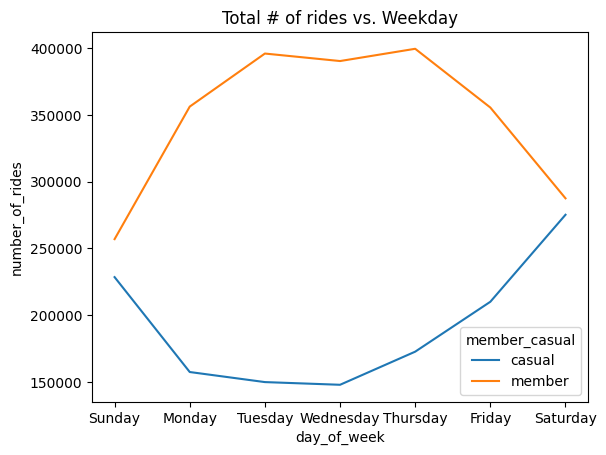

In [32]:
sns.lineplot(data=summary_stats, x='day_of_week', y='number_of_rides', hue='member_casual');
plt.title('Total # of rides vs. Weekday');

* \# of Members rides peaks on Tuesday and Thursday
* Members has mins on Sonday and Saturday, while Casual have maxs on those days
    * it can be said the the Casual and member curves mirror each other (i.e. they are complete opposites)
    * [EXCEPTION] on Wednesday both members and casuals reach a local minimum in # of rides

* As we move away from the weekend Casuals take much fewer bike trips and members take much more. 


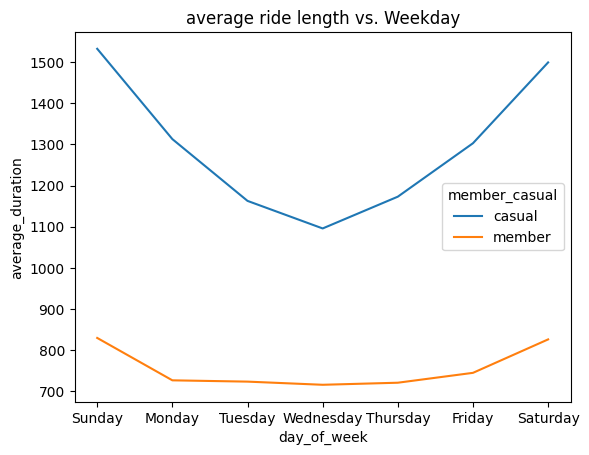

In [33]:
sns.lineplot(data=summary_stats, x='day_of_week', y='average_duration', hue='member_casual');
plt.title('average ride length vs. Weekday');

* Despite Casuals having fewer riders across all weekdays, they have nearly 1.5 ~ 2x the average duration in ride length compared to the members
* Also, it should be noted that member and casual curves follow positive parabolic curves over the course of the week.
    * the main difference is that that the deviation between ride lengths for member is **~100 secs OR 1min 40 secs**, while for casual is **~450 secs OR 7min 30 secs**

* It should be noted that the **weekday trip length for members is very uniform** (with max deviation of ~30secs)


In [77]:
summary_stats_2 = df.groupby(['member_casual', 'rideable_type', 'day_of_week'], observed=True).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('Trip_length [secs]', 'mean')
).reset_index()
summary_stats_2

,member_casual,rideable_type,day_of_week,number_of_rides,average_duration
0,casual,classic_bike,Sunday,121774,1948.002306
1,casual,classic_bike,Monday,76183,1759.191414
2,casual,classic_bike,Tuesday,69323,1604.118635
3,casual,classic_bike,Wednesday,66479,1500.832191
4,casual,classic_bike,Thursday,78595,1605.685305
5,casual,classic_bike,Friday,98844,1752.339535
6,casual,classic_bike,Saturday,146885,1901.726208
7,casual,electric_bike,Sunday,106724,1059.082138
8,casual,electric_bike,Monday,81336,895.013820
9,casual,electric_bike,Tuesday,80662,783.106515


In [52]:
summary_stats_2.to_csv("ride_type_breakdown.csv", index=False)

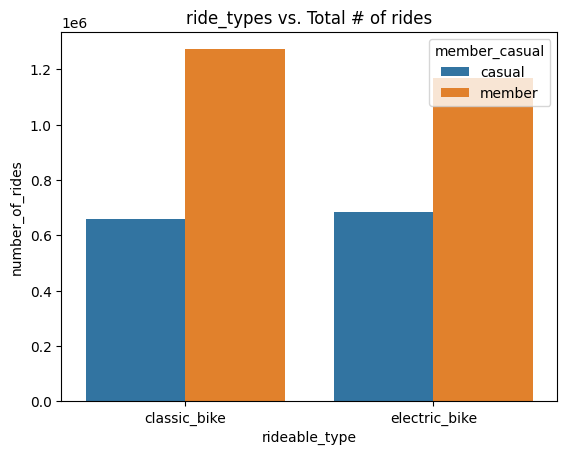

In [48]:
sns.barplot(data=summary_stats_2, x='rideable_type', y='number_of_rides', hue='member_casual');
plt.title('ride_types vs. Total # of rides');

* Casual use more electic bikes than classic, the difference is realtively small ~30K
* Members use more classic bikes than electric, the difference is more noticeable ~110K
* in both cases Members use more of each type than Casuals
    * for classics its around 614K
    * for electric the difference is a bit smaller, around 484K

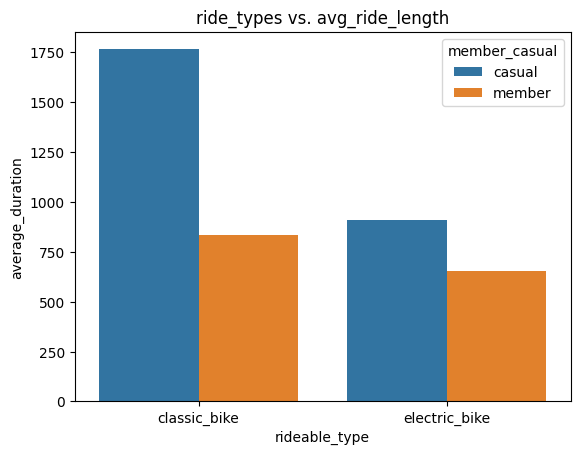

In [49]:
sns.barplot(data=summary_stats_2, x='rideable_type', y='average_duration', hue='member_casual');
plt.title('ride_types vs. avg_ride_length');

* in contrast with the previous chart, we can see that casuals use classic bike around 2x as long as members
* For electic bikes, the ride length is a lot closer
    * the difference is ~260 secs OR ~4mins 20secs

## Conclusions

* Casual riders use bikes predominential for lesiure [both weekdays and weekends]
    * This is due to the fact that the # of rides increases significantly s we approach the weekend, while it is at the smallest near the middle of the week
    * This is also mirror by the ride duration, high near weekend, very low near mid-week
* Member riders use bikes as a daily driver [to get to and from work on weekdays] and [for leisure on weekends]
    * This is due to the fact that weekday rides are very similar in duration (whether classic or electric)
        * They start and end in commercial areas of Chicago
        * and the majority of rides take place during the week, with a large drop off on the weekends